# Keyword Experiment: Top Words vs Paper Discovery

## Objective
This experiment investigates the relationship between the number of top keywords used in ADS searches and the discovery of relevant papers. We will test different numbers of top words (2, 3, 4, 5, 10) and analyze:

1. **Number of papers found** for each keyword count
2. **Overlap percentage** with WUMaCat database
3. **Optimal keyword count** for discovery vs precision

## Methodology
- Extract top N words from wordcloud analysis (titles + abstracts)
- For each N ∈ {2, 3, 4, 5, 10}:
  - Count total papers found
  - Retrieve all bibcodes
  - Compare with WUMaCat bibcodes
  - Calculate overlap percentage
- Visualize results with graphs

## Expected Outcomes
- **More keywords** → More papers found (broader search)
- **Fewer keywords** → Higher precision/overlap with WUMaCat
- Find optimal balance between discovery and relevance


## Setup and Imports


In [2]:
# Setup and imports
import sys
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Add the src directory to the path
sys.path.append('../src')

# Import our custom modules
from wordcloud_utils import get_top_keywords_from_wordclouds
from ads_parser import (
    test_ads_connection,
    count_publications_for_keywords,
    search_all_bibcodes
)

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("✅ Libraries imported successfully")
print("✅ Ready to start keyword experiment!")


✅ Libraries imported successfully
✅ Ready to start keyword experiment!


## Step 1: Test ADS Connection & Load Data


In [3]:
# Test ADS API connection
print("🚀 Testing ADS API connection...")
connection_ok = test_ads_connection()

if connection_ok:
    print("✅ ADS connection successful! Ready to proceed.")
else:
    print("❌ ADS connection failed. Please check your API token in .env file.")
    print("You can get an ADS API token from: https://ui.adsabs.harvard.edu/user/settings/token")

# Load WUMaCat data
print("\n📂 Loading WUMaCat baseline data...")
wumacat_file = '../data/WUMaCat.csv'

if os.path.exists(wumacat_file):
    wumacat_df = pd.read_csv(wumacat_file)
    wumacat_bibcodes = set(wumacat_df['Bibcode'].dropna().unique())
    print(f"✅ Loaded WUMaCat.csv")
    print(f"📊 Total unique bibcodes in WUMaCat: {len(wumacat_bibcodes):,}")
else:
    print(f"❌ WUMaCat file not found: {wumacat_file}")
    wumacat_bibcodes = set()


🚀 Testing ADS API connection...
🔍 Testing ADS API connection...
✅ ADS API connection successful!
   Found 1104 total results
   Retrieved 1 documents
✅ ADS connection successful! Ready to proceed.

📂 Loading WUMaCat baseline data...
✅ Loaded WUMaCat.csv
📊 Total unique bibcodes in WUMaCat: 424


## Step 2: Extract Different Keyword Sets


In [4]:
# Extract keyword sets for the experiment
print("�� Extracting keyword sets from wordcloud analysis...")

titles_freq_file = '../wordclouds/titles_word_frequencies.json'
abstracts_freq_file = '../wordclouds/abstracts_word_frequencies.json'

# Check if the wordcloud files exist
if not os.path.exists(titles_freq_file) or not os.path.exists(abstracts_freq_file):
    print("❌ Wordcloud frequency files not found!")
    print("Please run the wordcloud_analysis.ipynb notebook first to generate the frequency data.")
    print(f"Looking for:")
    print(f"  - {titles_freq_file}")
    print(f"  - {abstracts_freq_file}")
    experiment_keywords = {}
else:
    # First, extract top 25 keywords with filtering (like in exact_keyword_experiment)
    print("🎯 Extracting top 25 filtered keywords from wordcloud analysis...")
    top_keywords = get_top_keywords_from_wordclouds(
        titles_freq_file, 
        abstracts_freq_file, 
        top_n=25, 
        exclude_generic=True
    )
    
    print(f"\n🔍 Top {len(top_keywords)} filtered keywords available:")
    for i, keyword in enumerate(top_keywords, 1):
        print(f"   {i:2d}. {keyword}")
    
    # Define the numbers of keywords to test
    keyword_counts = [5, 7, 10, 15, 20]
    experiment_keywords = {}
    
    print(f"\n📝 Creating keyword sets for experiment:")
    print(f"Testing with: {keyword_counts} top words")
    
    for n in keyword_counts:
        # Take the first n keywords from the filtered list
        keywords = top_keywords[:n]
        experiment_keywords[n] = keywords
        print(f"  Top {n:2d} keywords ({len(keywords):2d} unique): {keywords}")
    
    print(f"\n✅ Successfully extracted {len(experiment_keywords)} keyword sets")

�� Extracting keyword sets from wordcloud analysis...
🎯 Extracting top 25 filtered keywords from wordcloud analysis...
✅ Extracted top 25 keywords for exact searching

🔍 Top 25 filtered keywords available:
    1. binary
    2. light
    3. contact
    4. period
    5. photometric
    6. mass
    7. type
    8. curves
    9. binaries
   10. eclipsing
   11. orbital
   12. ratio
   13. curve
   14. component
   15. star
   16. components
   17. massive
   18. solutions
   19. wilson
   20. devinney
   21. overcontact
   22. primary
   23. short
   24. stars
   25. secondary

📝 Creating keyword sets for experiment:
Testing with: [5, 7, 10, 15, 20] top words
  Top  5 keywords ( 5 unique): ['binary', 'light', 'contact', 'period', 'photometric']
  Top  7 keywords ( 7 unique): ['binary', 'light', 'contact', 'period', 'photometric', 'mass', 'type']
  Top 10 keywords (10 unique): ['binary', 'light', 'contact', 'period', 'photometric', 'mass', 'type', 'curves', 'binaries', 'eclipsing']
  Top 15 

## Step 3: Count Papers for Each Keyword Set


In [5]:
# Count papers for each keyword set
print("🔢 EXPERIMENT: Counting papers for different keyword counts")
print("="*70)

paper_counts = {}
search_field = "full"  # Use full text search

if experiment_keywords:
    for n in sorted(experiment_keywords.keys()):
        keywords = experiment_keywords[n]
        
        print(f"\n📊 Testing {n} keywords: {keywords}")
        
        # Count papers (silent mode to reduce output)
        count = count_publications_for_keywords(
            keywords, 
            search_fields=search_field, 
            description=f"{n} keywords",
            silent=True
        )
        
        paper_counts[n] = count
        print(f"   ✅ Found {count:,} papers")
    
    # Display summary
    print(f"\n📋 PAPER COUNT SUMMARY:")
    print("="*40)
    for n in sorted(paper_counts.keys()):
        print(f"  {n:2d} keywords: {paper_counts[n]:6,} papers")
    
    # Show trend
    if len(paper_counts) > 1:
        max_count = max(paper_counts.values())
        min_count = min(paper_counts.values())
        print(f"\n📈 TREND ANALYSIS:")
        print(f"  Range: {min_count:,} to {max_count:,} papers")
        print(f"  Ratio: {max_count/min_count:.1f}x difference between min and max")
        
else:
    print("❌ No keyword sets available for counting")
    paper_counts = {}


🔢 EXPERIMENT: Counting papers for different keyword counts

📊 Testing 5 keywords: ['binary', 'light', 'contact', 'period', 'photometric']
🔍 Searching for: full:binary AND full:light AND full:contact AND full:period AND full:photometric
✅ Found 12704 papers, retrieved 1
   ✅ Found 12,704 papers

📊 Testing 7 keywords: ['binary', 'light', 'contact', 'period', 'photometric', 'mass', 'type']
🔍 Searching for: full:binary AND full:light AND full:contact AND full:period AND full:photometric AND full:mass AND full:type
✅ Found 10241 papers, retrieved 1
   ✅ Found 10,241 papers

📊 Testing 10 keywords: ['binary', 'light', 'contact', 'period', 'photometric', 'mass', 'type', 'curves', 'binaries', 'eclipsing']
🔍 Searching for: full:binary AND full:light AND full:contact AND full:period AND full:photometric AND full:mass AND full:type AND full:curves AND full:binaries AND full:eclipsing
✅ Found 7644 papers, retrieved 1
   ✅ Found 7,644 papers

📊 Testing 15 keywords: ['binary', 'light', 'contact', 'pe

## Step 4: Retrieve Bibcodes for Each Keyword Set


In [6]:
# Retrieve all bibcodes for each keyword set
print("📥 EXPERIMENT: Retrieving bibcodes for each keyword set")
print("="*70)

experiment_bibcodes = {}

if experiment_keywords and paper_counts:
    for n in sorted(experiment_keywords.keys()):
        keywords = experiment_keywords[n]
        expected_count = paper_counts[n]
        
        print(f"\n🔍 Retrieving bibcodes for {n} keywords ({expected_count:,} papers expected)")
        print(f"   Keywords: {keywords}")
        
        # Retrieve all bibcodes (silent mode to reduce output)
        bibcodes = search_all_bibcodes(
            keywords, 
            search_fields=search_field,
            silent=True  # Keep it quiet for the experiment
        )
        
        experiment_bibcodes[n] = bibcodes
        print(f"   ✅ Retrieved {len(bibcodes):,} bibcodes")
        
        # Verify count matches expectation
        if len(bibcodes) != expected_count:
            diff = abs(len(bibcodes) - expected_count)
            print(f"   ⚠️  Count difference: {diff} (expected {expected_count:,}, got {len(bibcodes):,})")
    
    # Summary of retrieved bibcodes
    print(f"\n📋 BIBCODE RETRIEVAL SUMMARY:")
    print("="*50)
    total_api_requests = 0
    for n in sorted(experiment_bibcodes.keys()):
        count = len(experiment_bibcodes[n])
        # Estimate API requests used (rough calculation)
        requests_used = max(1, (count + 1999) // 2000) + 1  # +1 for initial count
        total_api_requests += requests_used
        print(f"  {n:2d} keywords: {count:6,} bibcodes (≈{requests_used} API requests)")
    
    print(f"\n📊 Total estimated API requests used: {total_api_requests}")
    
else:
    print("❌ No keyword sets or paper counts available")
    experiment_bibcodes = {}


📥 EXPERIMENT: Retrieving bibcodes for each keyword set

🔍 Retrieving bibcodes for 5 keywords (12,704 papers expected)
   Keywords: ['binary', 'light', 'contact', 'period', 'photometric']
   ✅ Retrieved 12,704 bibcodes

🔍 Retrieving bibcodes for 7 keywords (10,241 papers expected)
   Keywords: ['binary', 'light', 'contact', 'period', 'photometric', 'mass', 'type']
   ✅ Retrieved 10,241 bibcodes

🔍 Retrieving bibcodes for 10 keywords (7,644 papers expected)
   Keywords: ['binary', 'light', 'contact', 'period', 'photometric', 'mass', 'type', 'curves', 'binaries', 'eclipsing']
   ✅ Retrieved 7,644 bibcodes

🔍 Retrieving bibcodes for 15 keywords (5,790 papers expected)
   Keywords: ['binary', 'light', 'contact', 'period', 'photometric', 'mass', 'type', 'curves', 'binaries', 'eclipsing', 'orbital', 'ratio', 'curve', 'component', 'star']
   ✅ Retrieved 5,790 bibcodes

🔍 Retrieving bibcodes for 20 keywords (1,356 papers expected)
   Keywords: ['binary', 'light', 'contact', 'period', 'photometr

## Step 5: Compare with WUMaCat and Calculate Overlap


In [7]:
# Compare each keyword set with WUMaCat
print("🔍 EXPERIMENT: Comparing with WUMaCat database")
print("="*70)

experiment_results = {}

if experiment_bibcodes and wumacat_bibcodes:
    wumacat_count = len(wumacat_bibcodes)
    print(f"📚 WUMaCat baseline: {wumacat_count:,} bibcodes")
    
    for n in sorted(experiment_bibcodes.keys()):
        bibcodes = experiment_bibcodes[n]
        bibcodes_set = set(bibcodes)
        
        # Calculate overlaps
        overlap = bibcodes_set.intersection(wumacat_bibcodes)
        ads_only = bibcodes_set - wumacat_bibcodes
        wumacat_only = wumacat_bibcodes - bibcodes_set
        
        # Calculate percentages
        overlap_pct = (len(overlap) / len(bibcodes_set)) * 100 if bibcodes_set else 0
        coverage_pct = (len(overlap) / wumacat_count) * 100 if wumacat_count > 0 else 0
        
        # Store results
        experiment_results[n] = {
            'keywords': experiment_keywords[n],
            'total_papers': len(bibcodes),
            'overlap_count': len(overlap),
            'overlap_percentage': overlap_pct,
            'coverage_percentage': coverage_pct,
            'new_discoveries': len(ads_only),
            'missed_wumacat': len(wumacat_only)
        }
        
        print(f"\n📊 {n} keywords analysis:")
        print(f"   Total papers found:    {len(bibcodes):6,}")
        print(f"   Overlap with WUMaCat:  {len(overlap):6,} ({overlap_pct:5.1f}%)")
        print(f"   WUMaCat coverage:      {coverage_pct:5.1f}% ({len(overlap):,}/{wumacat_count:,})")
        print(f"   New discoveries:       {len(ads_only):6,}")
    
    # Create summary table
    print(f"\n📋 EXPERIMENT RESULTS SUMMARY:")
    print("="*80)
    print(f"{'Keywords':<10} {'Papers':<8} {'Overlap':<8} {'Overlap%':<9} {'Coverage%':<10} {'New':<8}")
    print("-" * 80)
    
    for n in sorted(experiment_results.keys()):
        r = experiment_results[n]
        print(f"{n:<10} {r['total_papers']:<8,} {r['overlap_count']:<8,} "
              f"{r['overlap_percentage']:<8.1f}% {r['coverage_percentage']:<9.1f}% {r['new_discoveries']:<8,}")
    
else:
    print("❌ Cannot perform comparison - missing data")
    experiment_results = {}


🔍 EXPERIMENT: Comparing with WUMaCat database
📚 WUMaCat baseline: 424 bibcodes

📊 5 keywords analysis:
   Total papers found:    12,704
   Overlap with WUMaCat:     371 (  2.9%)
   WUMaCat coverage:       87.5% (371/424)
   New discoveries:       12,333

📊 7 keywords analysis:
   Total papers found:    10,241
   Overlap with WUMaCat:     360 (  3.5%)
   WUMaCat coverage:       84.9% (360/424)
   New discoveries:        9,881

📊 10 keywords analysis:
   Total papers found:     7,644
   Overlap with WUMaCat:     354 (  4.6%)
   WUMaCat coverage:       83.5% (354/424)
   New discoveries:        7,290

📊 15 keywords analysis:
   Total papers found:     5,790
   Overlap with WUMaCat:     338 (  5.8%)
   WUMaCat coverage:       79.7% (338/424)
   New discoveries:        5,452

📊 20 keywords analysis:
   Total papers found:     1,356
   Overlap with WUMaCat:     244 ( 18.0%)
   WUMaCat coverage:       57.5% (244/424)
   New discoveries:        1,112

📋 EXPERIMENT RESULTS SUMMARY:
Keywords   P

## Step 6: Create Visualizations


📊 Creating visualizations of experiment results...
✅ Visualizations saved to: ../data/keyword_experiment_results.png


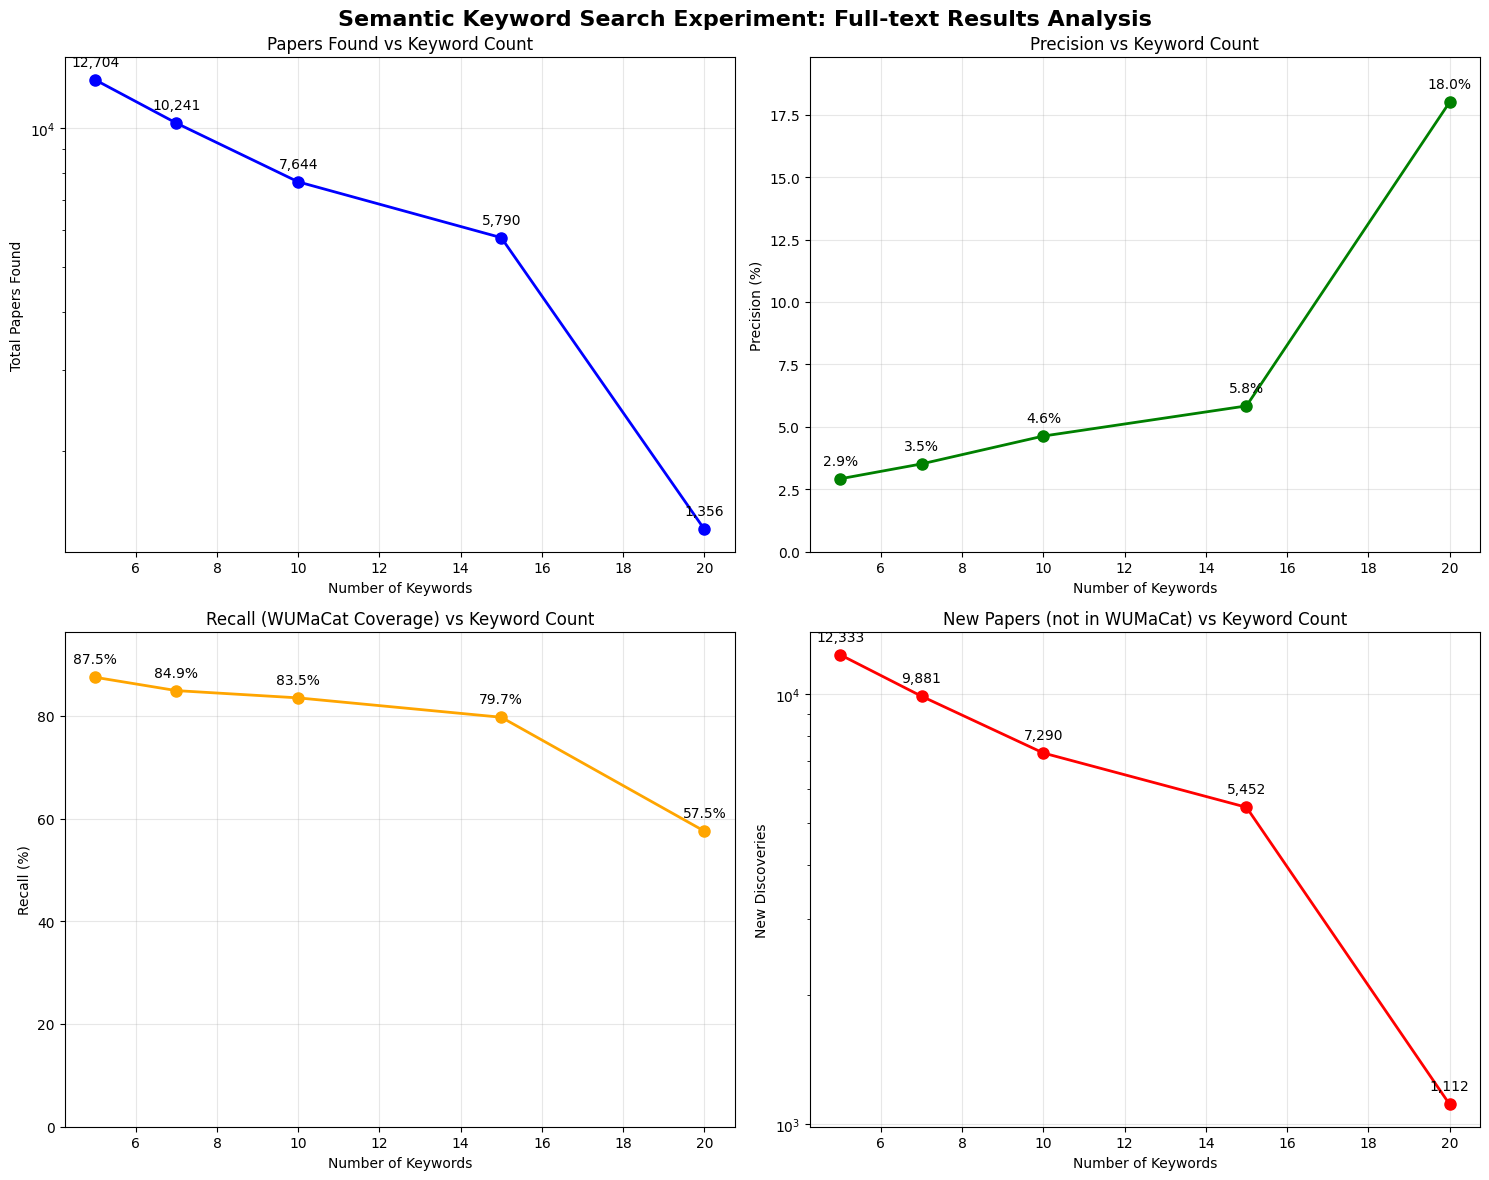

In [12]:
# Create visualizations of the experiment results
print("📊 Creating visualizations of experiment results...")

if experiment_results:
    # Prepare data for plotting
    keyword_counts = sorted(experiment_results.keys())
    total_papers = [experiment_results[n]['total_papers'] for n in keyword_counts]
    overlap_percentages = [experiment_results[n]['overlap_percentage'] for n in keyword_counts]
    coverage_percentages = [experiment_results[n]['coverage_percentage'] for n in keyword_counts]
    new_discoveries = [experiment_results[n]['new_discoveries'] for n in keyword_counts]
    
    # Create figure with subplots
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Semantic Keyword Search Experiment: Full-text Results Analysis', fontsize=16, fontweight='bold')
    
    # Plot 1: Number of papers found vs keyword count
    ax1.plot(keyword_counts, total_papers, 'o-', linewidth=2, markersize=8, color='blue')
    ax1.set_xlabel('Number of Keywords')
    ax1.set_ylabel('Total Papers Found')
    ax1.set_title('Papers Found vs Keyword Count')
    ax1.grid(True, alpha=0.3)
    ax1.set_yscale('log')  # Log scale for better visualization
    
    # Add value labels
    for i, (x, y) in enumerate(zip(keyword_counts, total_papers)):
        ax1.annotate(f'{y:,}', (x, y), textcoords="offset points", xytext=(0,10), ha='center')
    
    # Plot 2: Overlap percentage vs keyword count
    ax2.plot(keyword_counts, overlap_percentages, 'o-', linewidth=2, markersize=8, color='green')
    ax2.set_xlabel('Number of Keywords')
    ax2.set_ylabel('Precision (%)')
    ax2.set_title('Precision vs Keyword Count')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, max(overlap_percentages) * 1.1)
    
    # Add value labels
    for i, (x, y) in enumerate(zip(keyword_counts, overlap_percentages)):
        ax2.annotate(f'{y:.1f}%', (x, y), textcoords="offset points", xytext=(0,10), ha='center')
    
    # Plot 3: WUMaCat coverage vs keyword count
    ax3.plot(keyword_counts, coverage_percentages, 'o-', linewidth=2, markersize=8, color='orange')
    ax3.set_xlabel('Number of Keywords')
    ax3.set_ylabel('Recall (%)')
    ax3.set_title('Recall (WUMaCat Coverage) vs Keyword Count')
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim(0, max(coverage_percentages) * 1.1)
    
    # Add value labels
    for i, (x, y) in enumerate(zip(keyword_counts, coverage_percentages)):
        ax3.annotate(f'{y:.1f}%', (x, y), textcoords="offset points", xytext=(0,10), ha='center')
    
    # Plot 4: New discoveries vs keyword count
    ax4.plot(keyword_counts, new_discoveries, 'o-', linewidth=2, markersize=8, color='red')
    ax4.set_xlabel('Number of Keywords')
    ax4.set_ylabel('New Discoveries')
    ax4.set_title('New Papers (not in WUMaCat) vs Keyword Count')
    ax4.grid(True, alpha=0.3)
    ax4.set_yscale('log')  # Log scale for better visualization
    
    # Add value labels
    for i, (x, y) in enumerate(zip(keyword_counts, new_discoveries)):
        ax4.annotate(f'{y:,}', (x, y), textcoords="offset points", xytext=(0,10), ha='center')
    
    plt.tight_layout()
    
    # Save the figure
    output_file = '../data/keyword_experiment_results.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"✅ Visualizations saved to: {output_file}")
    
    plt.show()
    
else:
    print("❌ No experiment results available for visualization")


## Step 7: Save Experiment Results


In [14]:
# Save all experiment results to JSON file
print("💾 Saving experiment results...")

if experiment_results:
    # Prepare comprehensive results data in the same format as exact_keyword_experiment
    experiment_data = {
        'experiment_type': 'semantic_keyword_search',
        'timestamp': pd.Timestamp.now().isoformat(),
        'metadata': {
            'description': 'Semantic keyword search experiment using ADS embeddings',
            'search_method': 'semantic search using full:keyword syntax',
            'search_field': search_field,
            'wumacat_baseline_size': len(wumacat_bibcodes) if wumacat_bibcodes else 0,
            'keyword_counts_tested': sorted(experiment_results.keys()),
            'total_api_requests_estimated': sum(
                max(1, (experiment_results[n]['total_papers'] + 1999) // 2000) + 1 
                for n in experiment_results.keys()
            )
        },
        'results': {
            'source_field': search_field,
            'total_keywords_available': max(experiment_results.keys()) if experiment_results else 0,
            'wumacat_size': len(wumacat_bibcodes) if wumacat_bibcodes else 0,
            'combination_results': {}
        }
    }
    
    # Add detailed results for each keyword count in the same format
    for n in sorted(experiment_results.keys()):
        result = experiment_results[n]
        
        # Convert to the same structure as exact_keyword_experiment
        combination_result = {
            'keyword_count': n,
            'keywords': experiment_keywords[n] if n in experiment_keywords else [],
            'total_found': result['total_papers'],
            'retrieved': result['total_papers'],
            'bibcodes': experiment_bibcodes[n] if n in experiment_bibcodes else [],
            'overlap_count': result['overlap_count'],
            'overlap_percentage': result['overlap_percentage'],
            'precision': result['overlap_percentage'],  # Same as overlap_percentage in semantic search
            'wumacat_coverage': result['coverage_percentage']
        }
        
        experiment_data['results']['combination_results'][str(n)] = combination_result
    
    # Save to JSON file
    results_file = '../data/keyword_experiment_results.json'
    with open(results_file, 'w', encoding='utf-8') as f:
        json.dump(experiment_data, f, indent=2, ensure_ascii=False)
    
    print(f"✅ Complete experiment results saved to: {results_file}")
    
    # Save CSV summary in the format expected by growth analysis script
    # This should match the exact_keyword_experiment_comparison.csv format
    summary_df = pd.DataFrame({
        'Search_Field': ['Semantic Search'] * len(experiment_results),
        'Keywords_Count': sorted(experiment_results.keys()),
        'Keywords': [', '.join(experiment_keywords[n][:3]) + ('...' if len(experiment_keywords[n]) > 3 else '') 
                    if n in experiment_keywords else f'{n} keywords' 
                    for n in sorted(experiment_results.keys())],
        'Total_Papers': [experiment_results[n]['total_papers'] for n in sorted(experiment_results.keys())],
        'WUMaCat_Overlaps': [experiment_results[n]['overlap_count'] for n in sorted(experiment_results.keys())],
        'Precision_%': [experiment_results[n]['overlap_percentage'] for n in sorted(experiment_results.keys())],
        'Recall_%': [experiment_results[n]['coverage_percentage'] for n in sorted(experiment_results.keys())],
        'F1_Score_%': [2 * (experiment_results[n]['overlap_percentage'] * experiment_results[n]['coverage_percentage']) / 
                       (experiment_results[n]['overlap_percentage'] + experiment_results[n]['coverage_percentage']) 
                       if (experiment_results[n]['overlap_percentage'] + experiment_results[n]['coverage_percentage']) > 0 else 0
                       for n in sorted(experiment_results.keys())],
        'Efficiency': [experiment_results[n]['total_papers'] / max(1, experiment_results[n]['overlap_count']) 
                      for n in sorted(experiment_results.keys())],
        'Keywords_List': [experiment_keywords[n] if n in experiment_keywords else [] 
                         for n in sorted(experiment_results.keys())]
    })
    
    csv_file = '../data/keyword_experiment_summary.csv'
    summary_df.to_csv(csv_file, index=False)
    print(f"✅ Summary table saved to: {csv_file}")
    
    # Also save in the exact format expected by growth analysis (for direct comparison)
    growth_analysis_csv = '../data/keyword_experiment_growth_analysis.csv'
    growth_df = pd.DataFrame({
        'Search_Field': ['Semantic Search'] * len(experiment_results),
        'Keywords_Count': sorted(experiment_results.keys()),
        'Keywords': [', '.join(experiment_keywords[n][:3]) + ('...' if len(experiment_keywords[n]) > 3 else '') 
                    if n in experiment_keywords else f'{n} keywords' 
                    for n in sorted(experiment_results.keys())],
        'Total_Papers': [experiment_results[n]['total_papers'] for n in sorted(experiment_results.keys())],
        'WUMaCat_Overlaps': [experiment_results[n]['overlap_count'] for n in sorted(experiment_results.keys())],
        'Precision_%': [experiment_results[n]['overlap_percentage'] for n in sorted(experiment_results.keys())],
        'Recall_%': [experiment_results[n]['coverage_percentage'] for n in sorted(experiment_results.keys())],
        'F1_Score_%': [2 * (experiment_results[n]['overlap_percentage'] * experiment_results[n]['coverage_percentage']) / 
                       (experiment_results[n]['overlap_percentage'] + experiment_results[n]['coverage_percentage']) 
                       if (experiment_results[n]['overlap_percentage'] + experiment_results[n]['coverage_percentage']) > 0 else 0
                       for n in sorted(experiment_results.keys())],
        'Efficiency': [experiment_results[n]['total_papers'] / max(1, experiment_results[n]['overlap_count']) 
                      for n in sorted(experiment_results.keys())],
        'Keywords_List': [experiment_keywords[n] if n in experiment_keywords else [] 
                         for n in sorted(experiment_results.keys())]
    })
    
    growth_df.to_csv(growth_analysis_csv, index=False)
    print(f"✅ Growth analysis CSV saved to: {growth_analysis_csv}")
    
    # Display final summary
    print(f"\n🎯 EXPERIMENT CONCLUSIONS:")
    print("="*50)
    
    # Find optimal keyword counts
    best_overlap = max(experiment_results.keys(), key=lambda x: experiment_results[x]['overlap_percentage'])
    best_coverage = max(experiment_results.keys(), key=lambda x: experiment_results[x]['coverage_percentage'])
    most_papers = max(experiment_results.keys(), key=lambda x: experiment_results[x]['total_papers'])
    most_discoveries = max(experiment_results.keys(), key=lambda x: experiment_results[x]['new_discoveries'])
    
    print(f"�� Most papers found:     {most_papers} keywords ({experiment_results[most_papers]['total_papers']:,} papers)")
    print(f"�� Best overlap rate:     {best_overlap} keywords ({experiment_results[best_overlap]['overlap_percentage']:.1f}%)")
    print(f"📚 Best WUMaCat coverage: {best_coverage} keywords ({experiment_results[best_coverage]['coverage_percentage']:.1f}%)")
    print(f"🆕 Most new discoveries:  {most_discoveries} keywords ({experiment_results[most_discoveries]['new_discoveries']:,} papers)")
    
    print(f"\n💡 RECOMMENDATIONS:")
    print(f"   • For high precision: Use {best_overlap} keywords")
    print(f"   • For maximum discovery: Use {most_papers} keywords") 
    print(f"   • For balanced approach: Consider the trade-offs shown in graphs")
    
    # Save additional metadata for comparison with exact keyword experiment
    comparison_metadata = {
        'experiment_metadata': {
            'experiment_date': pd.Timestamp.now().isoformat(),
            'experiment_type': 'semantic_keyword_search',
            'search_fields_tested': [search_field],
            'keyword_combinations_tested': {
                'semantic_search': sorted(experiment_results.keys())
            },
            'wumacat_baseline_size': len(wumacat_bibcodes) if wumacat_bibcodes else 0,
            'top_keywords_used': experiment_keywords[min(experiment_results.keys())] if experiment_keywords else []
        },
        'results_summary': {
            'best_precision': {
                'field': search_field,
                'keywords_count': best_overlap,
                'precision': experiment_results[best_overlap]['overlap_percentage'],
                'keywords': experiment_keywords[best_overlap] if best_overlap in experiment_keywords else []
            },
            'best_recall': {
                'field': search_field,
                'keywords_count': best_coverage,
                'recall': experiment_results[best_coverage]['coverage_percentage'],
                'keywords': experiment_keywords[best_coverage] if best_coverage in experiment_keywords else []
            },
            'most_papers': {
                'field': search_field,
                'keywords_count': most_papers,
                'papers_found': experiment_results[most_papers]['total_papers'],
                'keywords': experiment_keywords[most_papers] if most_papers in experiment_keywords else []
            }
        },
        'detailed_results': {
            'semantic_search_results': experiment_data['results']
        }
    }
    
    # Save comparison metadata
    comparison_file = '../data/keyword_experiment_comparison_metadata.json'
    with open(comparison_file, 'w', encoding='utf-8') as f:
        json.dump(comparison_metadata, f, indent=2, ensure_ascii=False)
    
    print(f"✅ Comparison metadata saved to: {comparison_file}")
    
else:
    print("❌ No experiment results to save")

💾 Saving experiment results...
✅ Complete experiment results saved to: ../data/keyword_experiment_results.json
✅ Summary table saved to: ../data/keyword_experiment_summary.csv
✅ Growth analysis CSV saved to: ../data/keyword_experiment_growth_analysis.csv

🎯 EXPERIMENT CONCLUSIONS:
�� Most papers found:     5 keywords (12,704 papers)
�� Best overlap rate:     20 keywords (18.0%)
📚 Best WUMaCat coverage: 5 keywords (87.5%)
🆕 Most new discoveries:  5 keywords (12,333 papers)

💡 RECOMMENDATIONS:
   • For high precision: Use 20 keywords
   • For maximum discovery: Use 5 keywords
   • For balanced approach: Consider the trade-offs shown in graphs
✅ Comparison metadata saved to: ../data/keyword_experiment_comparison_metadata.json
